In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_excel('E:\Project\Credit_Risk_Analysis\Credit_Risk_Dataset.xlsx')

In [3]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [4]:
df.head()


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


In [118]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_ID,32581,32581,CUST_32581,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0


In [5]:
df.shape

(32581, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [121]:
df.isnull().sum()

client_ID                        0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
gender                           0
marital_status                   0
education_level                  0
country                          0
state                            0
city                             0
city_latitude                    0
city_longitude                   0
employment_type                  0
loan_term_months                 0
loan_to_income_ratio             0
other_debt                       0
debt_to_income_ratio             0
open_accounts                    0
credit_utilization_ratio         0
past_delinquencies  

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df.columns:
    if df[col].dtype == 'int64' and df[col].min() < 0:
        print(f"Column '{col}' has negative values.")
    elif df[col].dtype == 'float64' and df[col].min() < 0:
        print(f"Column '{col}' has negative values.")

Column 'city_longitude' has negative values.


In [9]:
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
df['person_emp_length'] = df.groupby('education_level')['person_emp_length'].transform(lambda x: x.fillna(x.median()))

df.isnull().sum()


client_ID                     0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
gender                        0
marital_status                0
education_level               0
country                       0
state                         0
city                          0
city_latitude                 0
city_longitude                0
employment_type               0
loan_term_months              0
loan_to_income_ratio          0
other_debt                    0
debt_to_income_ratio          0
open_accounts                 0
credit_utilization_ratio      0
past_delinquencies            0
dtype: int64

In [10]:
df_logic = df.query("person_age > 100 or person_emp_length > 85 or person_age <= 0 or person_emp_length < 0")
df_logic

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.593220,8.402454e+03,0.735635,14,0.495557,0
81,CUST_00082,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3,Male,Married,High School,USA,New York,New York City,40.7128,-74.0060,Full-time,24,0.019200,3.865941e+04,0.173838,4,0.080767,0
183,CUST_00184,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2,Female,Divorced,Bachelor,Canada,BC,Victoria,48.4284,-123.3656,Full-time,36,0.030000,5.487376e+04,0.304369,1,0.053672,0
210,CUST_00211,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4,Male,Single,High School,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.104167,3.265309e+04,0.274235,6,0.482647,1
575,CUST_00576,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3,Female,Single,High School,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,36,0.254987,2.133409e+04,0.521650,13,0.446131,0
747,CUST_00748,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4,Male,Single,High School,USA,New York,Buffalo,42.8864,-78.8784,Full-time,60,0.256410,1.094605e+04,0.396744,7,0.589120,1
32297,CUST_32298,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25,Male,Single,PhD,USA,Texas,Houston,29.7604,-95.3698,Self-employed,24,0.000833,1.187999e+06,0.198833,8,0.850584,0


In [11]:
median_age = df.loc[(df['person_age'] > 0) & (df['person_age'] <= 100), 'person_age'].median()
median_emp = df.loc[(df['person_emp_length'] >= 0) & (df['person_emp_length'] <= 85), 'person_emp_length'].median()

df.loc[df['person_age'] > 100, 'person_age'] = median_age
df.loc[df['person_age'] <= 0, 'person_age'] = median_age

df.loc[df['person_emp_length'] > 85, 'person_emp_length'] = median_emp
df.loc[df['person_emp_length'] < 0, 'person_emp_length'] = median_emp

In [12]:
df_logic = df.query("person_age > 100 or person_emp_length > 85 or person_age <= 0 or person_emp_length < 0")
df_logic

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies


In [13]:
labels = ["Young Adult", "Adult", "Middle-aged", "Senior"]
df["age_group"] = pd.qcut(df["person_age"], q=4, labels=labels)
df.head(5)

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,age_group
0,CUST_00001,22,59000,RENT,4.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0,Young Adult
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3,Young Adult
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0,Adult
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0,Young Adult
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0,Adult


In [16]:
df['person_home_ownership'] = df['person_home_ownership'].str.title()
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].replace({
    "Y": "Yes",
    "N": "No"
})
df['employment_type'] = df['employment_type'].str.title()
df['loan_intent'] = df['loan_intent'].str.title()

df.head()

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,age_group
0,CUST_00001,22,59000,Rent,4.0,Personal,D,35000,16.02,1,0.59,Yes,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-Employed,36,0.593220,8402.453850,0.735635,14,0.495557,0,Young Adult
1,CUST_00002,21,9600,Own,5.0,Education,B,1000,11.14,0,0.10,No,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-Time,36,0.104167,1607.802794,0.271646,10,0.585436,3,Young Adult
2,CUST_00003,25,9600,Mortgage,1.0,Medical,C,5500,12.87,1,0.57,No,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-Time,36,0.572917,2760.505633,0.860469,14,0.750732,0,Adult
3,CUST_00004,23,65500,Rent,4.0,Medical,C,35000,15.23,1,0.53,No,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-Time,12,0.534351,7155.286150,0.643592,15,0.379333,0,Young Adult
4,CUST_00005,24,54400,Rent,8.0,Medical,C,35000,14.27,1,0.55,Yes,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-Time,36,0.643382,15626.153439,0.930628,4,0.228103,0,Adult


In [18]:
df.to_excel('E:\Project\Credit_Risk_Analysis\Cleaned_Credit_Risk_Dataset.xlsx', index=False)

In [130]:
df = df.drop(columns=['client_ID', 'city_latitude', 'city_longitude'])
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,age_group
0,22,59000,Rent,4.0,Personal,D,35000,16.02,1,0.59,Y,3,Male,Married,High School,Canada,Ontario,Toronto,Self-Employed,36,0.593220,8402.453850,0.735635,14,0.495557,0,Young Adult
1,21,9600,Own,5.0,Education,B,1000,11.14,0,0.10,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,Full-Time,36,0.104167,1607.802794,0.271646,10,0.585436,3,Young Adult
2,25,9600,Mortgage,1.0,Medical,C,5500,12.87,1,0.57,N,3,Female,Married,Master,UK,Wales,Swansea,Full-Time,36,0.572917,2760.505633,0.860469,14,0.750732,0,Adult
3,23,65500,Rent,4.0,Medical,C,35000,15.23,1,0.53,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,Part-Time,12,0.534351,7155.286150,0.643592,15,0.379333,0,Young Adult
4,24,54400,Rent,8.0,Medical,C,35000,14.27,1,0.55,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,Part-Time,36,0.643382,15626.153439,0.930628,4,0.228103,0,Adult


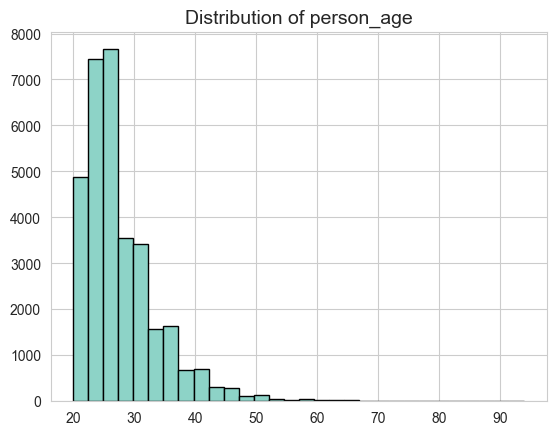

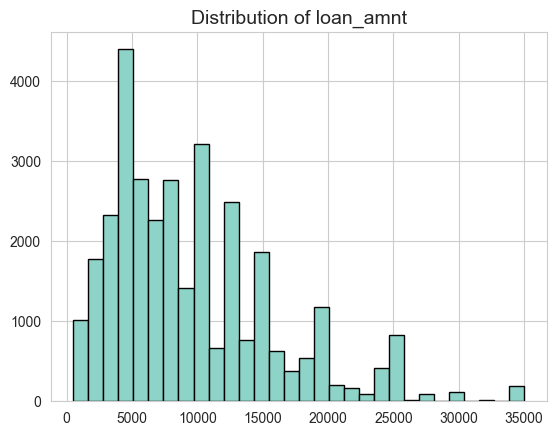

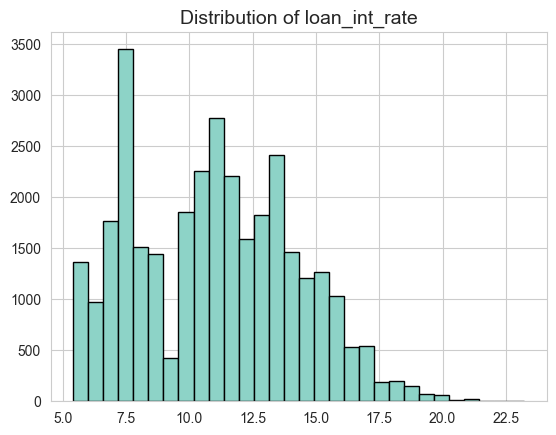

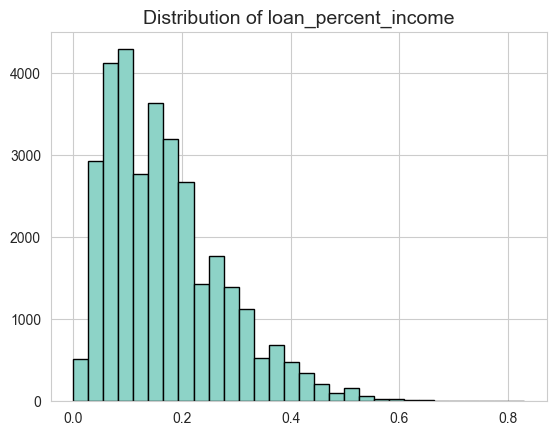

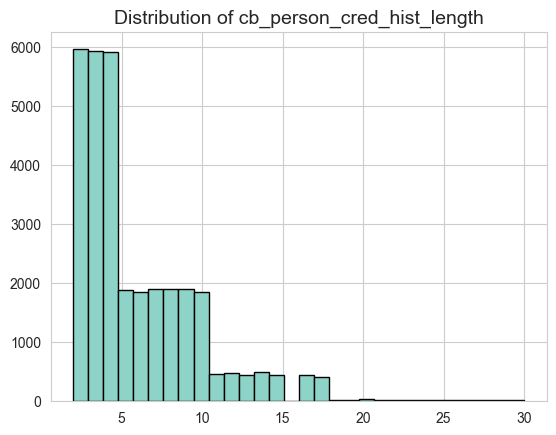

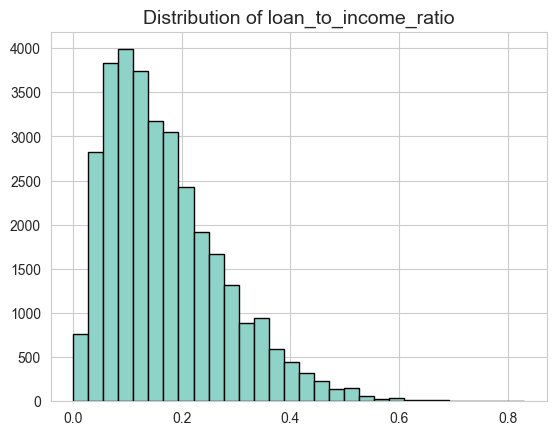

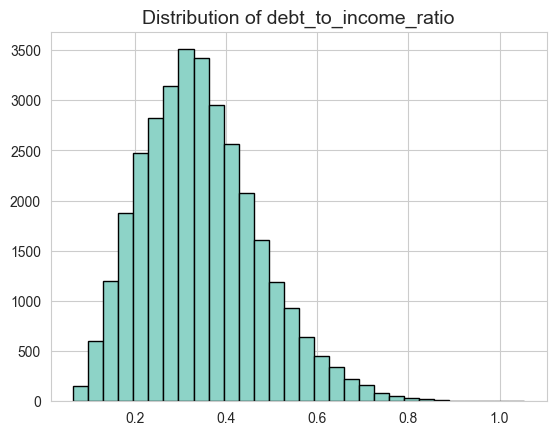

In [131]:
cols = ['person_age', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_to_income_ratio', 'debt_to_income_ratio']
for col in cols:
        df[col].hist(bins=30, edgecolor='black')
        plt.title("Distribution of " + col, fontsize=14)
        plt.show()
        

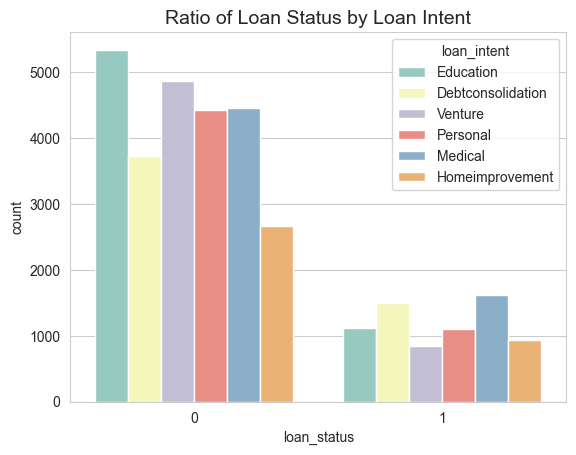

In [132]:
sns.countplot(x="loan_status", hue="loan_intent", data=df)
plt.title("Ratio of Loan Status by Loan Intent", fontsize=14)
plt.show()

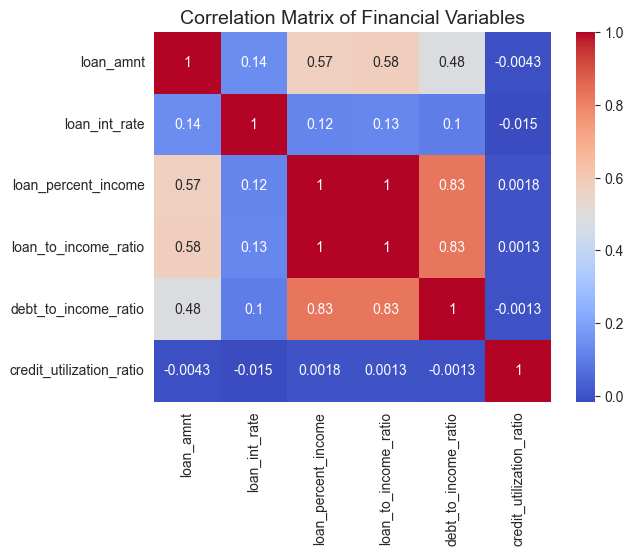

In [133]:
corr = df[['loan_amnt','loan_int_rate','loan_percent_income',
           'loan_to_income_ratio','debt_to_income_ratio',
           'credit_utilization_ratio']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Financial Variables", fontsize=14)
plt.show()

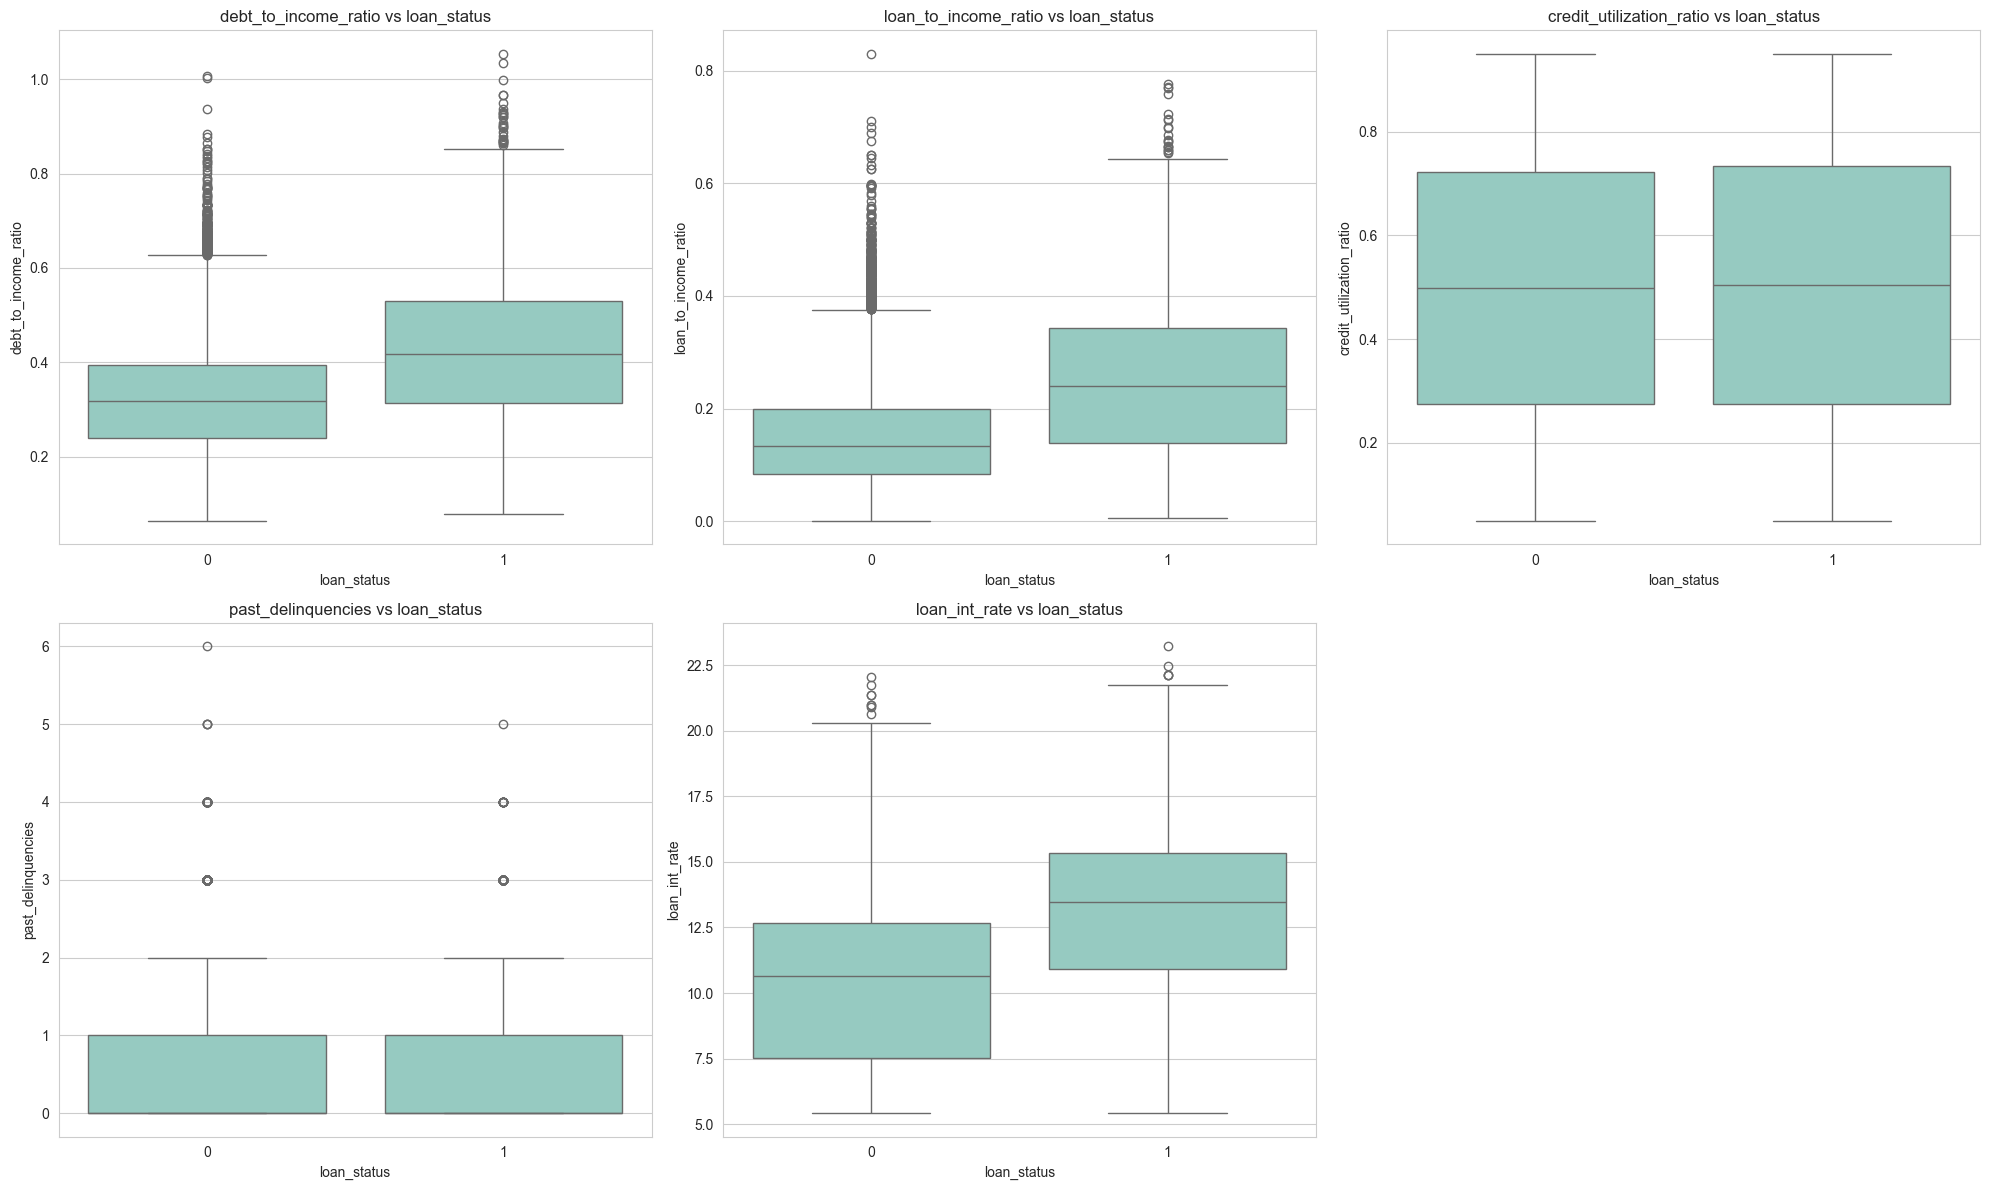

In [134]:
cols = [
    "debt_to_income_ratio",
    "loan_to_income_ratio",
    "credit_utilization_ratio",
    "past_delinquencies",
    "loan_int_rate"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

df = df.dropna(subset=cols + ["loan_status"])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(
        x="loan_status",
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs loan_status")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [135]:
categorical_col = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file", "gender", "marital_status", "education_level", "employment_type"]

C:\Users\kuron\AppData\Local\Temp\ipykernel_13776\3097284935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, palette="Set2", order=df[col].value_counts().index, data=df)
C:\Users\kuron\AppData\Local\Temp\ipykernel_13776\3097284935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, palette="Set2", order=df[col].value_counts().index, data=df)
C:\Users\kuron\AppData\Local\Temp\ipykernel_13776\3097284935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, palette="Set2", order=df[col].value_counts().index, data=df

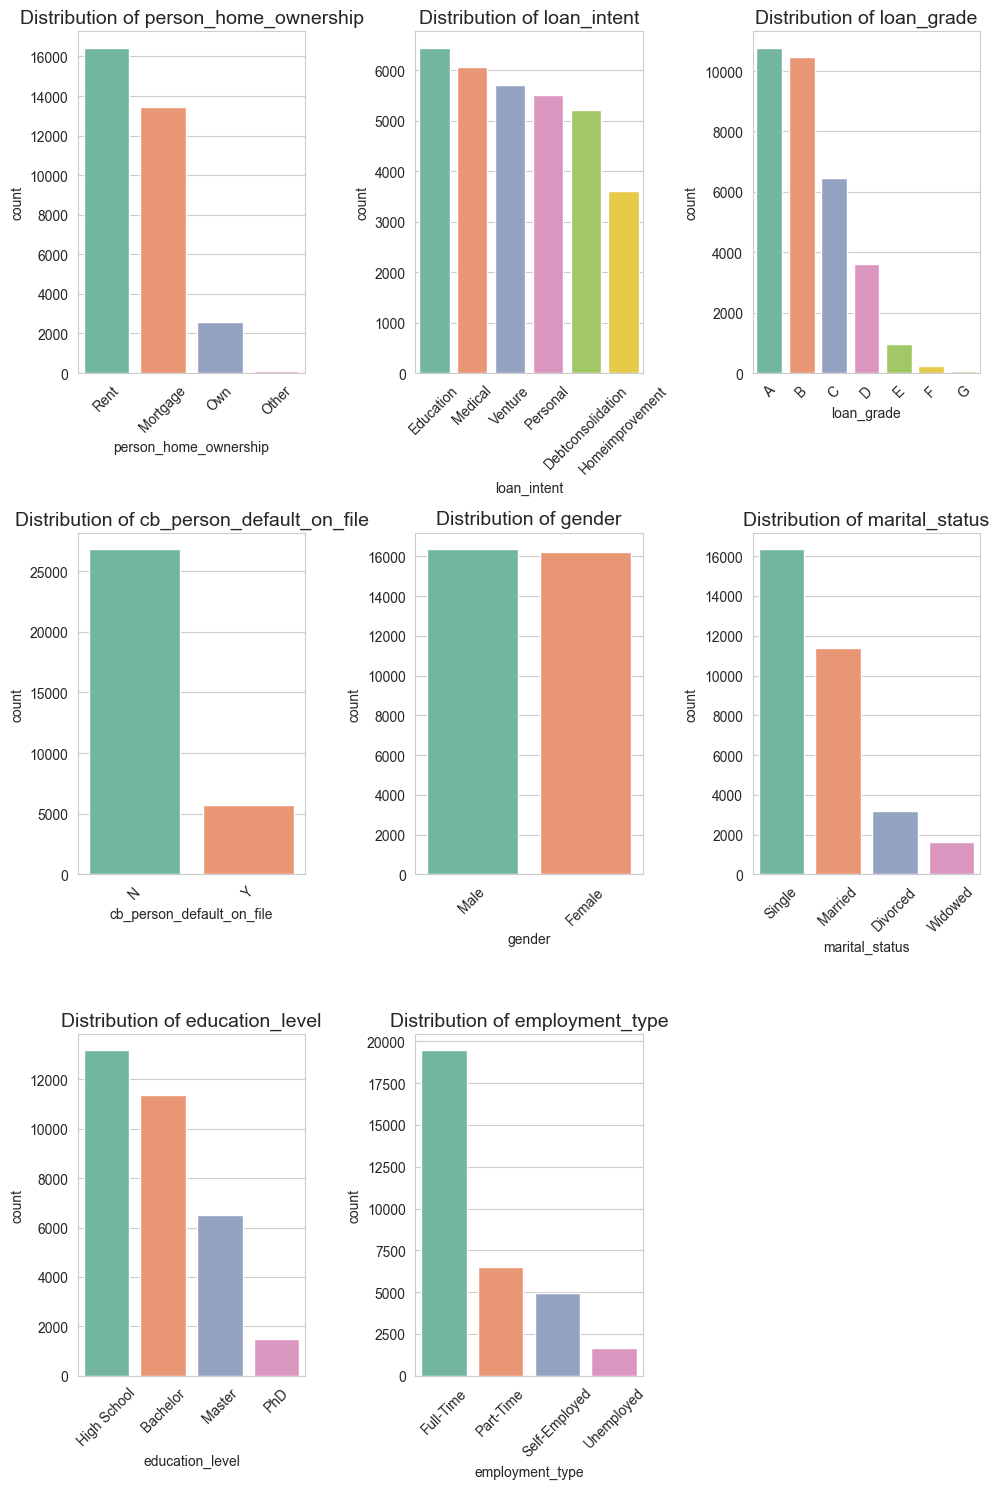

In [136]:
plt.figure(figsize=(10, 15))
for i, col in enumerate(categorical_col):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, palette="Set2", order=df[col].value_counts().index, data=df)
    plt.title(f"Distribution of {col}", fontsize=14)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [137]:
# Tỷ lệ nợ xấu theo nhóm tuổi và sở hữu nhà
pivot_table = pd.pivot_table(df, values='loan_status', index='person_home_ownership', columns=pd.cut(df['person_age'], bins=[0,25,35,50,100]), aggfunc='mean')
pivot_table

C:\Users\kuron\AppData\Local\Temp\ipykernel_13776\1699883380.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(df, values='loan_status', index='person_home_ownership', columns=pd.cut(df['person_age'], bins=[0,25,35,50,100]), aggfunc='mean')


person_age,"(0, 25]","(25, 35]","(35, 50]","(50, 100]"
person_home_ownership,,,,
Mortgage,0.127649,0.124544,0.121256,0.141414
Other,0.323077,0.275862,0.307692,NaN
Own,0.075671,0.071902,0.082734,0.050000
Rent,0.328156,0.302315,0.303689,0.353659


In [138]:
# Trung bình khoản vay và thu nhập theo quốc gia
pivot_table_2 = pd.pivot_table(df, values=['loan_amnt','person_income'], index='country', aggfunc='mean')
pivot_table_2

,loan_amnt,person_income
country,,
Canada,9641.784886,65874.769124
UK,9574.045139,66305.939053
USA,9552.736823,66040.642831


In [139]:
df.groupby('gender')["loan_amnt"].mean()

gender
Female    9567.917952
Male      9610.613280
Name: loan_amnt, dtype: float64

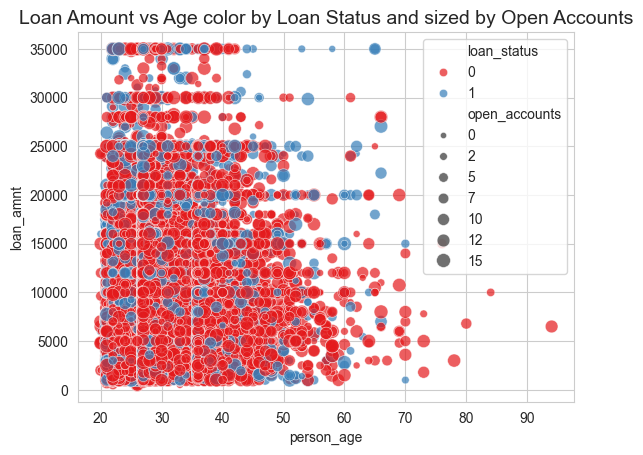

In [140]:
sns.scatterplot(data=df, x='person_age', y='loan_amnt', hue='loan_status', size='open_accounts', sizes=(20, 100), alpha=0.7, palette='Set1')
plt.title("Loan Amount vs Age color by Loan Status and sized by Open Accounts", fontsize=14)
plt.show()

C:\Users\kuron\AppData\Local\Temp\ipykernel_13776\921721161.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="loan_intent", y="loan_amnt", data=df, palette="Set3")


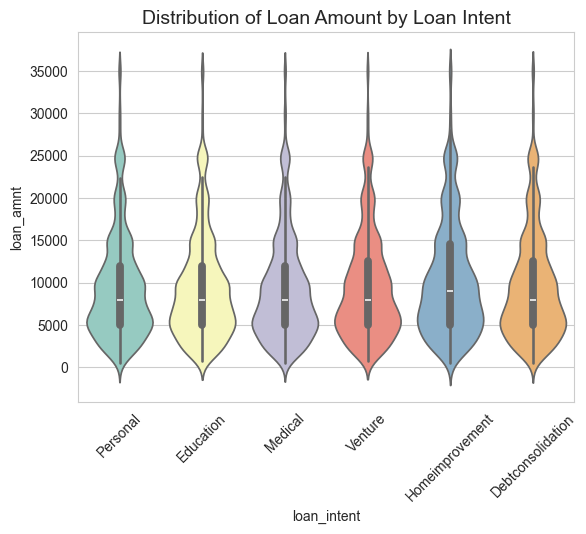

In [141]:
sns.violinplot(x="loan_intent", y="loan_amnt", data=df, palette="Set3")
plt.title("Distribution of Loan Amount by Loan Intent", fontsize=14)
plt.xticks(rotation=45)
plt.show()

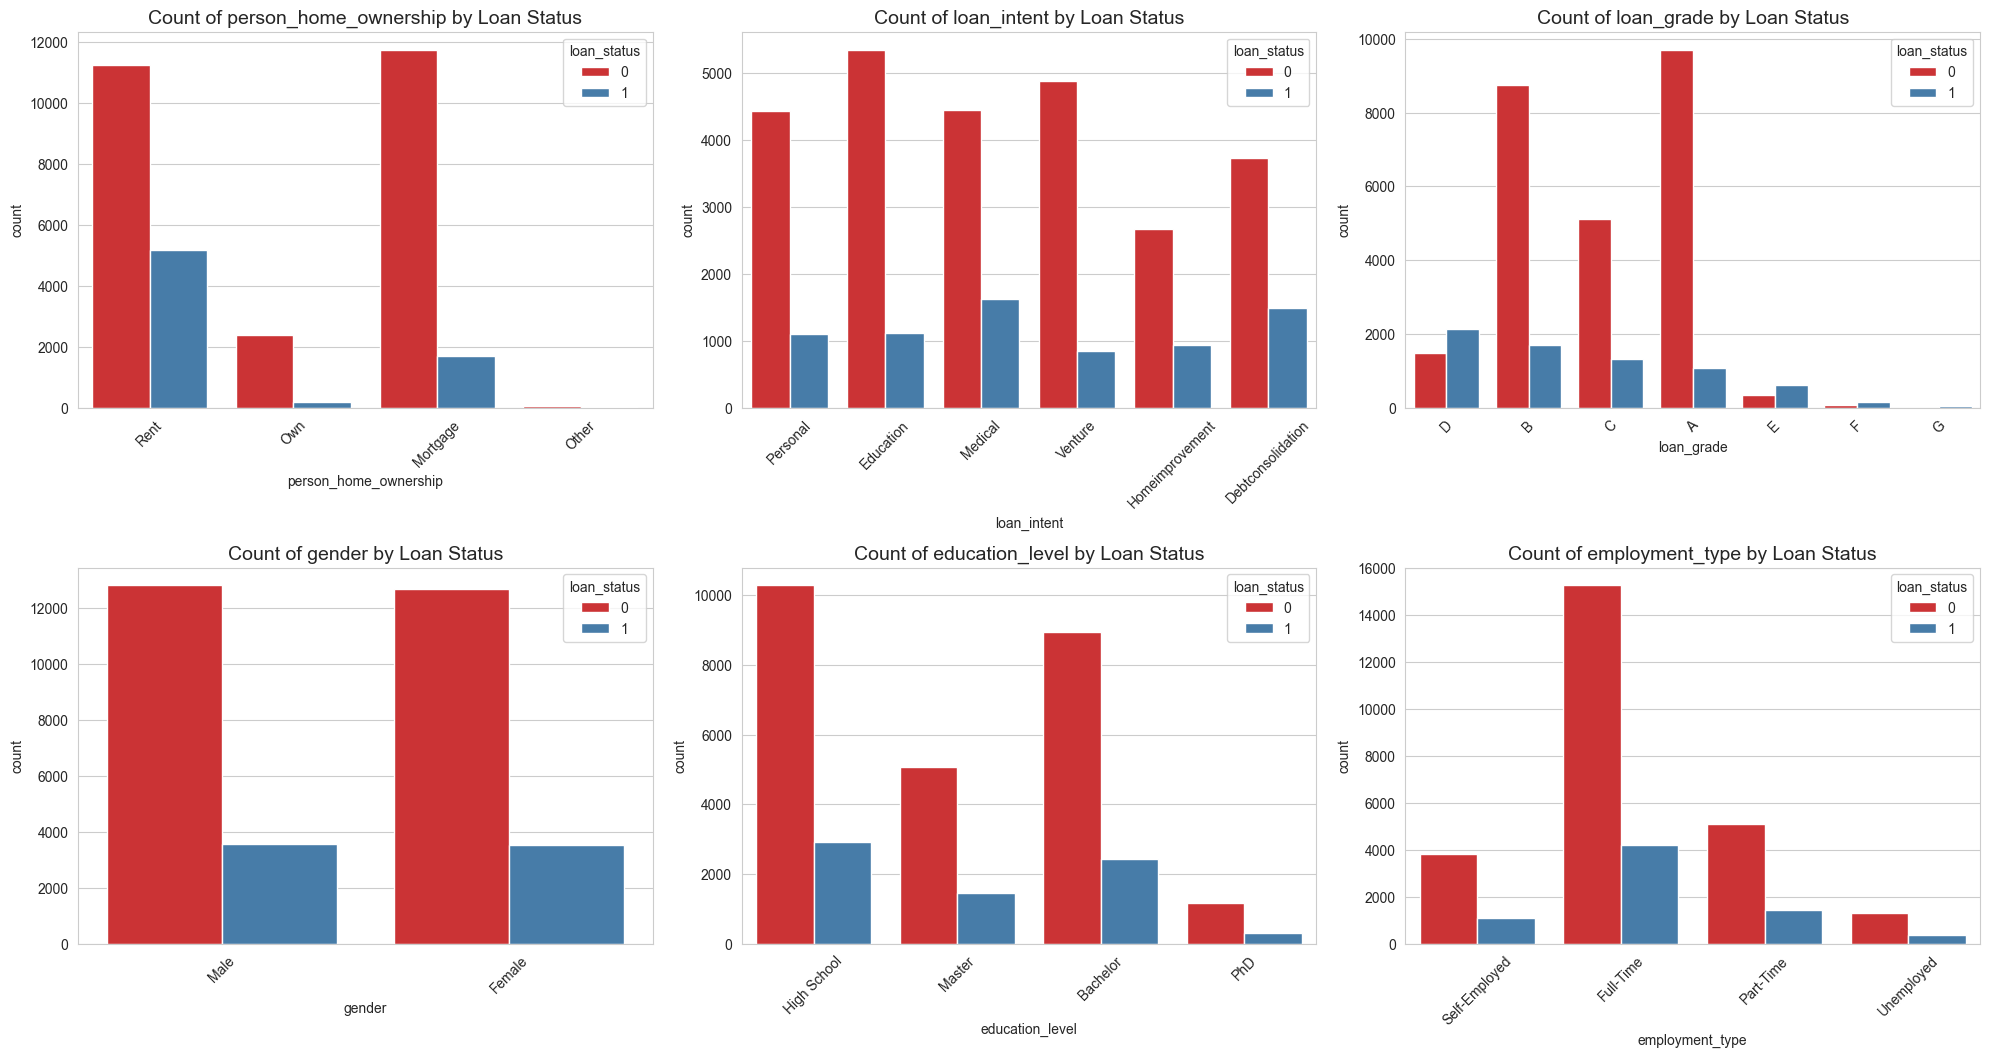

In [142]:
cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'gender', 'education_level', 'employment_type']
plt.figure(figsize=(20, 15))
for i, col in enumerate(cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(x=col, hue="loan_status", data=df, palette="Set1")
    plt.title(f"Count of {col} by Loan Status", fontsize=14)
    plt.xticks(rotation=45)
    
plt.tight_layout()    
plt.show()

In [143]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import joblib

In [144]:
num_features = [
        "person_income",
        "loan_amnt",
        "loan_to_income_ratio",
        "debt_to_income_ratio",
        "loan_percent_income",
        "other_debt",
        "loan_int_rate",
        "credit_utilization_ratio",
        "past_delinquencies",
        "cb_person_cred_hist_length",
        "person_emp_length",
        "loan_term_months",
    ]

cat_features = [
        "employment_type",
        "person_home_ownership",
        "loan_intent",
        "loan_grade",
        "cb_person_default_on_file",
        "country",
    ]

df_model = df[num_features + cat_features].copy()
df_model.head()

,person_income,loan_amnt,loan_to_income_ratio,debt_to_income_ratio,loan_percent_income,other_debt,loan_int_rate,credit_utilization_ratio,past_delinquencies,cb_person_cred_hist_length,person_emp_length,loan_term_months,employment_type,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file,country
0,59000,35000,0.593220,0.735635,0.59,8402.453850,16.02,0.495557,0,3,4.0,36,Self-Employed,Rent,Personal,D,Y,Canada
1,9600,1000,0.104167,0.271646,0.10,1607.802794,11.14,0.585436,3,2,5.0,36,Full-Time,Own,Education,B,N,Canada
2,9600,5500,0.572917,0.860469,0.57,2760.505633,12.87,0.750732,0,3,1.0,36,Full-Time,Mortgage,Medical,C,N,UK
3,65500,35000,0.534351,0.643592,0.53,7155.286150,15.23,0.379333,0,2,4.0,12,Part-Time,Rent,Medical,C,N,Canada
4,54400,35000,0.643382,0.930628,0.55,15626.153439,14.27,0.228103,0,4,8.0,36,Part-Time,Rent,Medical,C,Y,USA


In [145]:
X = df_model
y = df["loan_status"]

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [147]:
X_train.shape

(26064, 18)

In [148]:
X_test.shape

(6517, 18)

In [149]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [150]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    print(classification_report(y_test, y_pred))
    return best_model, acc, grid_search.best_params_, roc_auc

In [151]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", solver="lbfgs")
lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
}

In [152]:
rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [153]:
gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1, 0.2, 0.3],
    "classifier__max_depth": [3, 5, 7, None]
}

In [154]:
best_score = 0  
best_overall_model = None
best_model_name = None

models = {
    "Logistic Regression": (lr, lr_param_grid),
    "Random Forest": (rf, rf_param_grid),
    "Gradient Boosting": (gb, gb_param_grid)
}

for name, (model, param_grid) in models.items():
    print(f"\nTraining {name}...")

    best_model, acc, best_params, roc_auc = train_model(
        model, param_grid,
        X_train, y_train,
        X_test, y_test
    )

    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Best params: {best_params}")

    if roc_auc > best_score:
        best_score = roc_auc
        best_overall_model = best_model
        best_model_name = name

print(f"\n Best Model: {best_model_name} (ROC-AUC = {best_score:.4f})")


Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      5095
           1       0.56      0.79      0.66      1422

    accuracy                           0.82      6517
   macro avg       0.75      0.81      0.77      6517
weighted avg       0.85      0.82      0.83      6517

Accuracy: 0.8197
ROC-AUC: 0.8793
Best params: {'classifier__C': 10, 'classifier__penalty': 'l2'}

Training Random Forest...
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5095
           1       0.97      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517

Accuracy: 0.9319
ROC-AUC: 0.9255
Best params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Traini

In [155]:
import os

def save_model(model, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump(model, path)
    print(f"Model saved to {path}")

save_model(best_overall_model, "models/best_credit_model.pkl")

Model saved to models/best_credit_model.pkl
